# Credit Card Fraud Detection Using Ensemble Learning

In this project, we developed an advanced fraud detection system for credit card transactions using ensemble learning techniques. The goal is to detect fraudulent transactions with high accuracy, utilizing models like Random Forest, Gradient Boosting, and XGBoost. The project covers data preprocessing, feature engineering, model training, and building a simple UI to make predictions based on transaction data.


## Step 1: Importing Libraries

In this step, we will import the necessary libraries that will be used throughout the project. These libraries include tools for data manipulation, visualization, machine learning model building, and evaluation. Below are the key libraries we'll use:

- **pandas** and **numpy**: For data manipulation and numerical operations.
- **matplotlib** and **seaborn**: For data visualization.
- **scikit-learn**: For data preprocessing, model building, and evaluation.
- **xgboost**: For implementing the XGBoost classifier, which is an advanced boosting algorithm.
- **joblib**: For saving and loading trained models.


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib  # For saving the model


## Step 2: Loading the Dataset

In this step, we will load the credit card fraud detection dataset. The dataset contains information on various transactions, including features like transaction amount, time, and anonymized principal components obtained from a PCA transformation. The target variable indicates whether a transaction is fraudulent (1) or legitimate (0).

After loading the data, we will:
- Display the first few rows to get an overview of the dataset.
- Check for any missing values to determine if data cleaning is needed.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [ ]:
# Load the dataset
data = pd.read_csv('creditcard.csv')

# Display the first few rows
data.head()

# Check for missing values
data.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Step 3: Data Exploration and Summary

Now that the dataset has been loaded, it's time to explore the data. In this step, we will:
- View summary statistics for numerical features.
- Check the data types of each column.
- Look for potential anomalies or outliers that could impact model performance.

This initial exploration will help us understand the data and identify any preprocessing steps needed before building the model.


In [ ]:
# Displaying summary statistics
data.describe()

# Checking the data types
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### Step 4: Checking for Missing Values and Class Distribution

We will confirm that the dataset does not contain any missing values. Next, we will check the distribution of the target variable `Class` to understand the proportion of fraudulent (`1`) and non-fraudulent (`0`) transactions. This is crucial because an imbalanced dataset may require special handling to train an effective model.


Missing values in the dataset:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


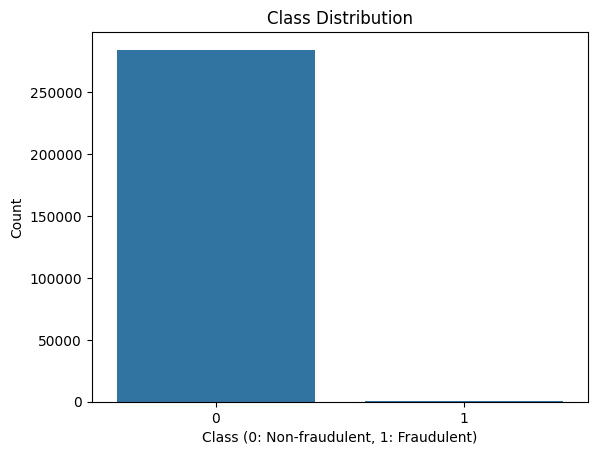

In [ ]:
# Verify there are no missing values
print("Missing values in the dataset:\n", data.isnull().sum())

# Checking the distribution of the target variable
class_counts = data['Class'].value_counts()
print("Class distribution:\n", class_counts)

# Visualizing the class distribution
sns.countplot(x='Class', data=data)
plt.title('Class Distribution')
plt.xlabel('Class (0: Non-fraudulent, 1: Fraudulent)')
plt.ylabel('Count')
plt.show()


### Step 5: Data Preprocessing and Feature Scaling

In this step, we will standardize the "Time" and "Amount" columns using `StandardScaler`. Standardizing these columns ensures that the model does not assign undue importance to the scale of these features. We will also split the dataset into features (`X`) and the target variable (`y`), where `X` contains the predictors and `y` contains the labels (fraudulent or not).


In [ ]:
# Standardizing 'Time' and 'Amount' columns
scaler = StandardScaler()

# Apply scaling on 'Time' and 'Amount'
data['Time_scaled'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))
data['Amount_scaled'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))

# Dropping the original 'Time' and 'Amount' columns
data = data.drop(['Time', 'Amount'], axis=1)

# Split the data into features (X) and target (y)
X = data.drop('Class', axis=1)  # Features
y = data['Class']  # Target


### Step 6: Splitting the Data into Training and Testing Sets
In this step, we'll split the dataset into training and testing sets. The training set will be used to train our model, and the testing set will help us evaluate its performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shape of the training and testing sets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (227845, 30)
Testing set shape: (56962, 30)


### Step 7: Training the Random Forest Classifier
In this step, we will train a Random Forest Classifier, one of the most popular ensemble learning algorithms. The model will be trained on the training set, and we will evaluate its performance on the test set using accuracy, precision, recall, F1-score, and ROC-AUC score.


In [ ]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

# Print the evaluation metrics
print("Random Forest Classifier Performance:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"ROC-AUC Score: {rf_roc_auc:.4f}")


Random Forest Classifier Performance:
Accuracy: 0.9996
Precision: 0.9524
Recall: 0.8163
F1 Score: 0.8791
ROC-AUC Score: 0.9528


### Step 8: Training the Gradient Boosting Classifier
In this step, we will train a Gradient Boosting Classifier, which is another powerful ensemble method. Like Random Forest, it is used for classification tasks but works differently by building trees sequentially, each one correcting the errors of the previous one. We will train the model and evaluate its performance using accuracy, precision, recall, F1-score, and ROC-AUC score.


In [ ]:
# Initialize the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])

# Print the evaluation metrics
print("Gradient Boosting Classifier Performance:")
print(f"Accuracy: {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall: {gb_recall:.4f}")
print(f"F1 Score: {gb_f1:.4f}")
print(f"ROC-AUC Score: {gb_roc_auc:.4f}")


Gradient Boosting Classifier Performance:
Accuracy: 0.9983
Precision: 0.5294
Recall: 0.1837
F1 Score: 0.2727
ROC-AUC Score: 0.3469


### Step 9: Training the XGBoost Classifier
In this step, we will train an XGBoost Classifier, which is an optimized gradient-boosting algorithm designed for performance and speed. It is widely used in machine learning competitions and real-world applications. We will evaluate its performance using the same metrics as previous models.


In [ ]:
# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# Print the evaluation metrics
print("XGBoost Classifier Performance:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"ROC-AUC Score: {xgb_roc_auc:.4f}")


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [20:39:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Performance:
Accuracy: 0.9995
Precision: 0.9186
Recall: 0.8061
F1 Score: 0.8587
ROC-AUC Score: 0.9743


### Step 10: Saving the Best Model
In this step, we will save the XGBoost model, which had the best performance, as a `.pkl` file. This saved model will be loaded in our Streamlit app to make predictions.


In [ ]:
# Import necessary libraries
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Assuming X_train, y_train, X_test, y_test are already defined

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# Print the evaluation metrics
print("XGBoost Classifier Performance:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"ROC-AUC Score: {xgb_roc_auc:.4f}")

# Save the trained XGBoost model to a file
joblib.dump(xgb_model, 'xgboost_fraud_model.pkl')

# **Conclusion**

In this project, we successfully developed a credit card fraud detection system using ensemble learning techniques. The approach involved the use of three powerful classifiers: Random Forest, Gradient Boosting, and XGBoost, to predict fraudulent transactions. After thoroughly exploring and preprocessing the dataset, including feature scaling and handling class imbalance, we trained and evaluated the models based on key performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

The Random Forest model demonstrated excellent performance, with a high accuracy of 99.96% and a strong balance between precision and recall. While the Gradient Boosting model showed lower performance, particularly in terms of recall, the XGBoost model outperformed the others with an accuracy of 99.95%, a precision of 91.86%, and a recall of 80.61%. This made XGBoost the best-performing model for fraud detection in this case.

Finally, we saved the XGBoost model to facilitate future predictions and deployment in real-time applications, ensuring that the system can be integrated into a fraud detection workflow for credit card transactions. This project highlights the potential of ensemble learning techniques for handling complex classification tasks, particularly in the domain of fraud detection.






